<a href="https://colab.research.google.com/github/Sanjan193/High-Entropy-Alloys-Comparative-Machine-Learning-for-Metal-State-Prediction/blob/main/Notebooks/Models_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Imports**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
import seaborn as sns
from sklearn.model_selection import train_test_split
import lazypredict
from lazypredict.Supervised import LazyClassifier
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


In [ ]:
# checking the dataset
data = pd.read_csv("/content/cleaned_dataframe.csv",
                   encoding='latin1')

data.head(5).T


,0,1,2,3,4
Al,0.060000,0.060000,0.060000,0.200000,0.200000
Co,0.000000,0.000000,0.000000,0.000000,0.000000
Cr,0.000000,0.000000,0.000000,0.200000,0.200000
Fe,0.000000,0.000000,0.000000,0.000000,0.000000
Ni,0.000000,0.000000,0.000000,0.000000,0.000000
Cu,0.000000,0.000000,0.000000,0.000000,0.000000
Mn,0.000000,0.000000,0.000000,0.000000,0.000000
Ti,0.280000,0.280000,0.280000,0.200000,0.200000
V,0.040000,0.040000,0.040000,0.000000,0.000000
Nb,0.200000,0.200000,0.200000,0.200000,0.200000


# **Splitting Data and Labels**

In [ ]:
# data
df_data = data.iloc[:,:-1]
#label
df_label = data.iloc[:,-1]

# **Normalizing The Data**
**Applying z score normalization in the feature columns**

In [ ]:
scaler = StandardScaler().set_output(transform="pandas")
scaled_data = scaler.fit_transform(data)

In [ ]:
scaled_data.head(5).T

,0,1,2,3,4
Al,0.037128,0.037128,0.037128,1.759967,1.759967
Co,-1.139940,-1.139940,-1.139940,-1.139940,-1.139940
Cr,-1.225068,-1.225068,-1.225068,0.640737,0.640737
Fe,-1.058413,-1.058413,-1.058413,-1.058413,-1.058413
Ni,-1.304745,-1.304745,-1.304745,-1.304745,-1.304745
Cu,-0.290626,-0.290626,-0.290626,-0.290626,-0.290626
Mn,-0.553561,-0.553561,-0.553561,-0.553561,-0.553561
Ti,1.775503,1.775503,1.775503,1.085225,1.085225
V,0.151501,0.151501,0.151501,-0.372005,-0.372005
Nb,1.425566,1.425566,1.425566,1.425566,1.425566


# **Splliting the data set into train test**

In [ ]:
data_train,data_test,target_train,target_test = train_test_split(scaled_data,
                                                                 df_label,
                                                                 test_size= 0.20,
                                                                 random_state=42,
                                                                 shuffle=False)

In [ ]:
for i in list(data_train.columns):
  if data_train[i].isnull().any():
    print(i)
  else :
    print(f"{i} column is Fully filled")

Al column is Fully filled
Co column is Fully filled
Cr column is Fully filled
Fe column is Fully filled
Ni column is Fully filled
Cu column is Fully filled
Mn column is Fully filled
Ti column is Fully filled
V column is Fully filled
Nb column is Fully filled
Mo column is Fully filled
Zr column is Fully filled
Hf column is Fully filled
Ta column is Fully filled
W column is Fully filled
C column is Fully filled
Mg column is Fully filled
Zn column is Fully filled
Si column is Fully filled
Re column is Fully filled
N column is Fully filled
Sc column is Fully filled
Li column is Fully filled
Sn column is Fully filled
Be column is Fully filled
Num_of_Elem column is Fully filled
Density_calc column is Fully filled
dHmix column is Fully filled
dSmix column is Fully filled
dGmix column is Fully filled
Tm column is Fully filled
n.Para column is Fully filled
Atom.Size.Diff column is Fully filled
Elect.Diff column is Fully filled
VEC column is Fully filled
Sythesis_Route column is Fully filled
Hom

# **Training Models**

**applying the lazypredict classifier to compare multiple classification models at once**

In [ ]:

clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
Results, predictions = clf.fit(data_train, data_test, target_train, target_test)

print(Results)

                               Accuracy  Balanced Accuracy   ROC AUC  \
Model                                                                  
BaggingClassifier              1.000000           1.000000  1.000000   
DecisionTreeClassifier         1.000000           1.000000  1.000000   
LinearDiscriminantAnalysis     1.000000           1.000000  1.000000   
LGBMClassifier                 1.000000           1.000000  1.000000   
GaussianNB                     0.974790           0.963889  0.975000   
CalibratedClassifierCV         0.957983           0.954096  0.997717   
ExtraTreeClassifier            0.857143           0.927966  0.900322   
ExtraTreesClassifier           0.966387           0.825000  0.999582   
RandomForestClassifier         0.966387           0.825000  0.999162   
LogisticRegression             0.966387           0.825000  0.988610   
LinearSVC                      0.932773           0.804096       NaN   
SGDClassifier                  0.924370           0.797222      

## **PLotting The ROC AUC and Accuracy Results For Each Model**

**ROC AUC**

/tmp/ipykernel_1501/1057228839.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model',y = 'ROC AUC',data= Results,palette='husl')


([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24],
 [Text(0, 0, 'BaggingClassifier'),
  Text(1, 0, 'DecisionTreeClassifier'),
  Text(2, 0, 'LinearDiscriminantAnalysis'),
  Text(3, 0, 'LGBMClassifier'),
  Text(4, 0, 'GaussianNB'),
  Text(5, 0, 'CalibratedClassifierCV'),
  Text(6, 0, 'ExtraTreeClassifier'),
  Text(7, 0, 'ExtraTreesClassifier'),
  Text(8, 0, 'RandomForestClassifier'),
  Text(9, 0, 'LogisticRegression'),
  Text(10, 0, 'LinearSVC'),
  Text(11, 0, 'SGDClassifier'),
  Text(12, 0, 'QuadraticDiscriminantAnalysis'),
  Text(13, 0, 'SVC'),
  Text(14, 0, 'PassiveAggressiveClassifier'),
  Text(15, 0, 'LabelSpreading'),
  Text(16, 0, 'LabelPropagation'),
  Text(17, 0, 'Perceptron'),
  Text(18, 0, 'RidgeClassifier'),
  Text(19, 0, 'RidgeClassifierCV'),
  Text(20, 0, 'NearestCentroid'),
  Text(21, 0, 'BernoulliNB'),
  Text(22, 0, 'KNeighborsClassifier'),
  Text(23, 0, 'AdaBoostClassifier'),
  Text

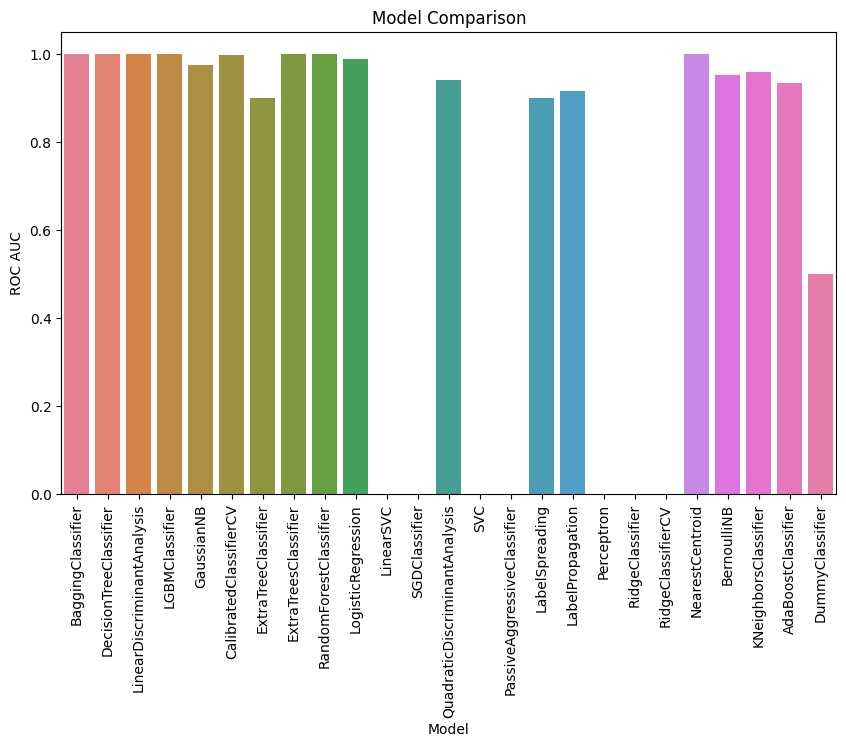

In [ ]:
plt.figure(figsize =(10,6))
plt.title("Model Comparison")
sns.barplot(x='Model',y = 'ROC AUC',data= Results,palette='husl')
plt.xticks(rotation = 90)

**Accuracy**

/tmp/ipykernel_1501/3808775551.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model',y = 'Accuracy',data=Results,palette='husl')


([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24],
 [Text(0, 0, 'BaggingClassifier'),
  Text(1, 0, 'DecisionTreeClassifier'),
  Text(2, 0, 'LinearDiscriminantAnalysis'),
  Text(3, 0, 'LGBMClassifier'),
  Text(4, 0, 'GaussianNB'),
  Text(5, 0, 'CalibratedClassifierCV'),
  Text(6, 0, 'ExtraTreeClassifier'),
  Text(7, 0, 'ExtraTreesClassifier'),
  Text(8, 0, 'RandomForestClassifier'),
  Text(9, 0, 'LogisticRegression'),
  Text(10, 0, 'LinearSVC'),
  Text(11, 0, 'SGDClassifier'),
  Text(12, 0, 'QuadraticDiscriminantAnalysis'),
  Text(13, 0, 'SVC'),
  Text(14, 0, 'PassiveAggressiveClassifier'),
  Text(15, 0, 'LabelSpreading'),
  Text(16, 0, 'LabelPropagation'),
  Text(17, 0, 'Perceptron'),
  Text(18, 0, 'RidgeClassifier'),
  Text(19, 0, 'RidgeClassifierCV'),
  Text(20, 0, 'NearestCentroid'),
  Text(21, 0, 'BernoulliNB'),
  Text(22, 0, 'KNeighborsClassifier'),
  Text(23, 0, 'AdaBoostClassifier'),
  Text

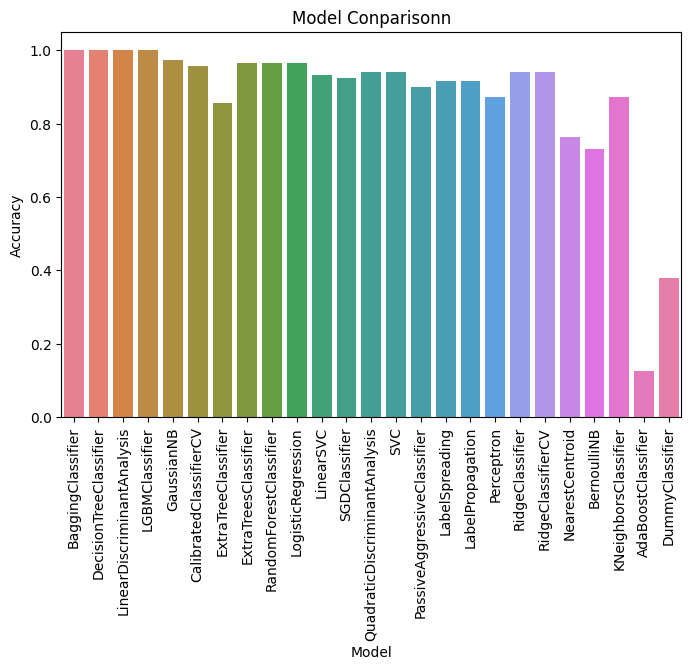

In [ ]:
plt.figure(figsize =(8,5))
plt.title("Model Conparisonn")
sns.barplot(x='Model',y = 'Accuracy',data=Results,palette='husl')
plt.xticks(rotation = 90)

# **Applying PCA To The Features**

**Keeping here the highest principal component which has 99% varience**

In [ ]:
pca = PCA(n_components=0.99)
pca_data  = pca.fit_transform(scaled_data)

**Trainn Test Splitting**

In [ ]:
pca_train_x,pca_x_test,label_train,label_test = train_test_split(pca_data,df_label,test_size=.2,shuffle=False,random_state=42)

**Applying The Classifiers**

In [ ]:
clf_2 = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
pca_Results, pca_predictions = clf.fit(pca_train_x, pca_x_test,label_train,label_test)


In [ ]:
pca_Results

,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Precision,Recall,Time Taken
Model,,,,,,,
LinearDiscriminantAnalysis,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.062788
LogisticRegression,0.991597,0.975000,0.987335,0.991422,0.991779,0.991597,0.100090
LGBMClassifier,0.932773,0.945339,0.990861,0.940334,0.960990,0.932773,0.630848
SGDClassifier,0.957983,0.908333,NaN,0.957464,0.959727,0.957983,0.075312
AdaBoostClassifier,0.941176,0.880414,0.967520,0.940650,0.942145,0.941176,0.527589
PassiveAggressiveClassifier,0.840336,0.849011,NaN,0.854405,0.889108,0.840336,0.055828
NearestCentroid,0.949580,0.816525,0.989168,0.947247,0.945981,0.949580,0.081970
CalibratedClassifierCV,0.932773,0.804096,0.997210,0.928109,0.936330,0.932773,1.075885
LinearSVC,0.932773,0.804096,NaN,0.928109,0.936330,0.932773,0.083333


# **Plottings After Applying PCA**

**ROC AUC**

/tmp/ipykernel_1501/1129062010.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model',y = 'ROC AUC',data= pca_Results,palette='husl')


([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24],
 [Text(0, 0, 'LinearDiscriminantAnalysis'),
  Text(1, 0, 'LogisticRegression'),
  Text(2, 0, 'LGBMClassifier'),
  Text(3, 0, 'SGDClassifier'),
  Text(4, 0, 'AdaBoostClassifier'),
  Text(5, 0, 'PassiveAggressiveClassifier'),
  Text(6, 0, 'NearestCentroid'),
  Text(7, 0, 'CalibratedClassifierCV'),
  Text(8, 0, 'LinearSVC'),
  Text(9, 0, 'RandomForestClassifier'),
  Text(10, 0, 'SVC'),
  Text(11, 0, 'ExtraTreesClassifier'),
  Text(12, 0, 'QuadraticDiscriminantAnalysis'),
  Text(13, 0, 'DecisionTreeClassifier'),
  Text(14, 0, 'Perceptron'),
  Text(15, 0, 'BaggingClassifier'),
  Text(16, 0, 'LabelPropagation'),
  Text(17, 0, 'LabelSpreading'),
  Text(18, 0, 'RidgeClassifier'),
  Text(19, 0, 'RidgeClassifierCV'),
  Text(20, 0, 'ExtraTreeClassifier'),
  Text(21, 0, 'BernoulliNB'),
  Text(22, 0, 'KNeighborsClassifier'),
  Text(23, 0, 'GaussianNB'),
  Text

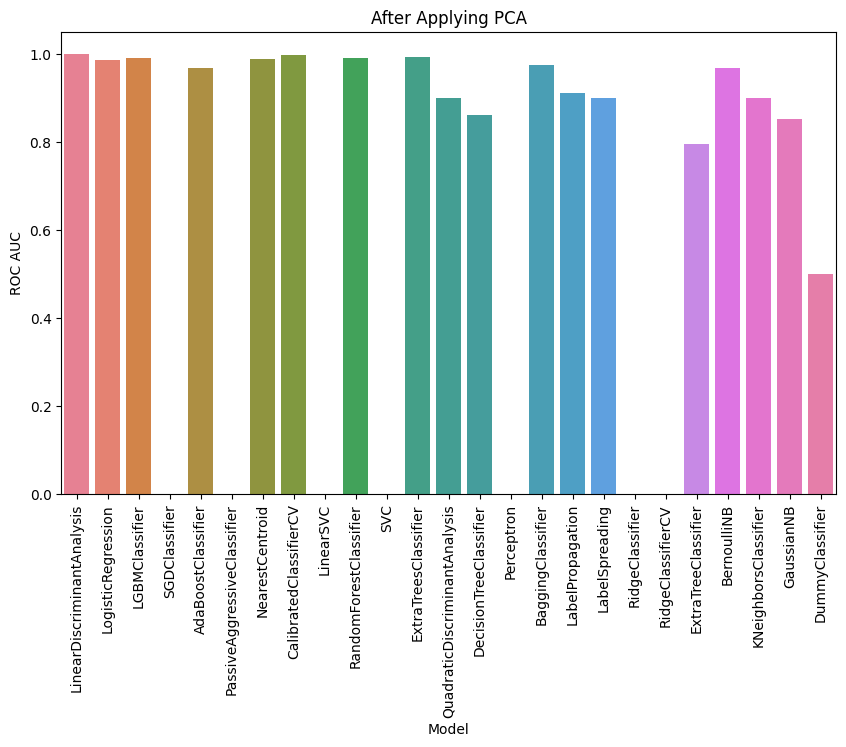

In [ ]:
plt.figure(figsize =(10,6))
plt.title("After Applying PCA")
sns.barplot(x='Model',y = 'ROC AUC',data= pca_Results,palette='husl')
plt.xticks(rotation = 90)

**Accuracy**

/tmp/ipykernel_1501/1923209465.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model',y = 'Accuracy',data= pca_Results,palette='husl')


([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24],
 [Text(0, 0, 'LinearDiscriminantAnalysis'),
  Text(1, 0, 'LogisticRegression'),
  Text(2, 0, 'LGBMClassifier'),
  Text(3, 0, 'SGDClassifier'),
  Text(4, 0, 'AdaBoostClassifier'),
  Text(5, 0, 'PassiveAggressiveClassifier'),
  Text(6, 0, 'NearestCentroid'),
  Text(7, 0, 'CalibratedClassifierCV'),
  Text(8, 0, 'LinearSVC'),
  Text(9, 0, 'RandomForestClassifier'),
  Text(10, 0, 'SVC'),
  Text(11, 0, 'ExtraTreesClassifier'),
  Text(12, 0, 'QuadraticDiscriminantAnalysis'),
  Text(13, 0, 'DecisionTreeClassifier'),
  Text(14, 0, 'Perceptron'),
  Text(15, 0, 'BaggingClassifier'),
  Text(16, 0, 'LabelPropagation'),
  Text(17, 0, 'LabelSpreading'),
  Text(18, 0, 'RidgeClassifier'),
  Text(19, 0, 'RidgeClassifierCV'),
  Text(20, 0, 'ExtraTreeClassifier'),
  Text(21, 0, 'BernoulliNB'),
  Text(22, 0, 'KNeighborsClassifier'),
  Text(23, 0, 'GaussianNB'),
  Text

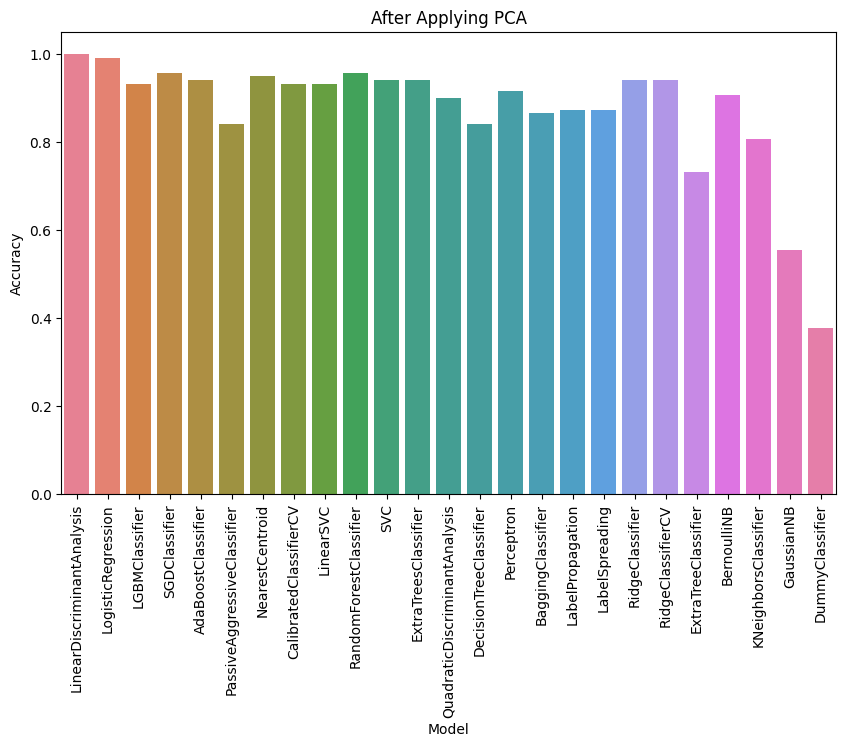

In [ ]:
plt.figure(figsize =(10,6))
plt.title("After Applying PCA")
sns.barplot(x='Model',y = 'Accuracy',data= pca_Results,palette='husl')
plt.xticks(rotation = 90)

# **Conclusion**

**After applyling PCA we can see that the overall accuracy of models has increased**
